# 3-2 수업 내용
1. Transformer
2. 파운데이션 모델
3. Transformer 기반, 사물인식 모델
4. Transformer 기반, 이미지 생성 멀티모달 모델

# 1. 수업 목표
- 이제 Transformer 까지 도착했습니다.
  - MLP 시대 -> 딥러닝 시대(CNN) -> Transformer
  - 요즘 딥러닝을 한다고 하면 대부분 Transformer 구조를 택하는 시대입니다.
- 이번 주제는 Transformer / Foundation Model / Multi-Modal Foundation Model입니다.

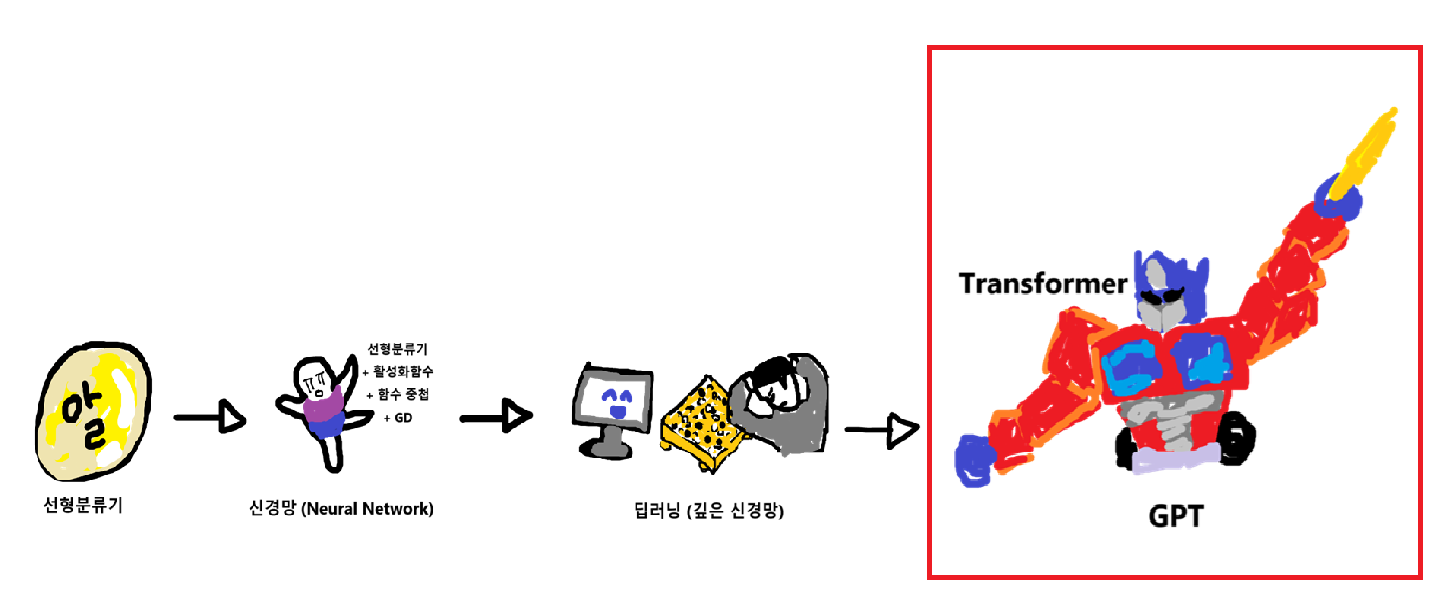

# 2. 시계열 모델(RNN) 부터 Transformer 까지

### 시계열 데이터와 시계열 모델

- 시간에 흐름 or 순서에 따라 기록된 자료를 **시계열데이터**라고 합니다.
  - 대표적으로 주식차트가 있습니다!
  - 그리고 음성데이터도 있습니다.
  - 그 중 문장도 시계열에 속합니다.
    왜냐면 왼쪽에서 오른쪽 순서로 보아야 의미가 있는 데이터이라서요.

- 시계열 **모델**은 뭘 할수있을까요?
  - 대표적으로 주가 예측을 할수 있습니다. 성능이 좋다면 미래를 예측하여 부자가 될수 있죠.
  - 기온도 예측할 수 있고, 차트로 그릴 수 있는 것은 예측이 가능합니다.
  - 문장에 다음 단어를 예측할 수 도 있어요.

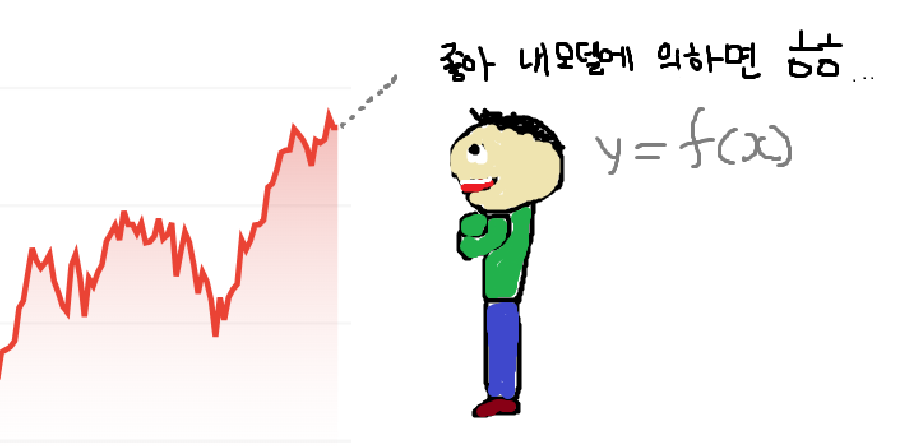

### RNN 모델로 시계열 모델이 시작되었습니다.
- RNN(Recurrent Nueral Network)은 아래와 같은 구조를 갖습니다.
  - h는 히든레이어를 표현했습니다.
  

- 오른쪽 그림을 보시면 히든레이어어 쪽에 뭔가 순환(Recurrent)하죠? 그래서 이름이 Recurrent NN 입니다.

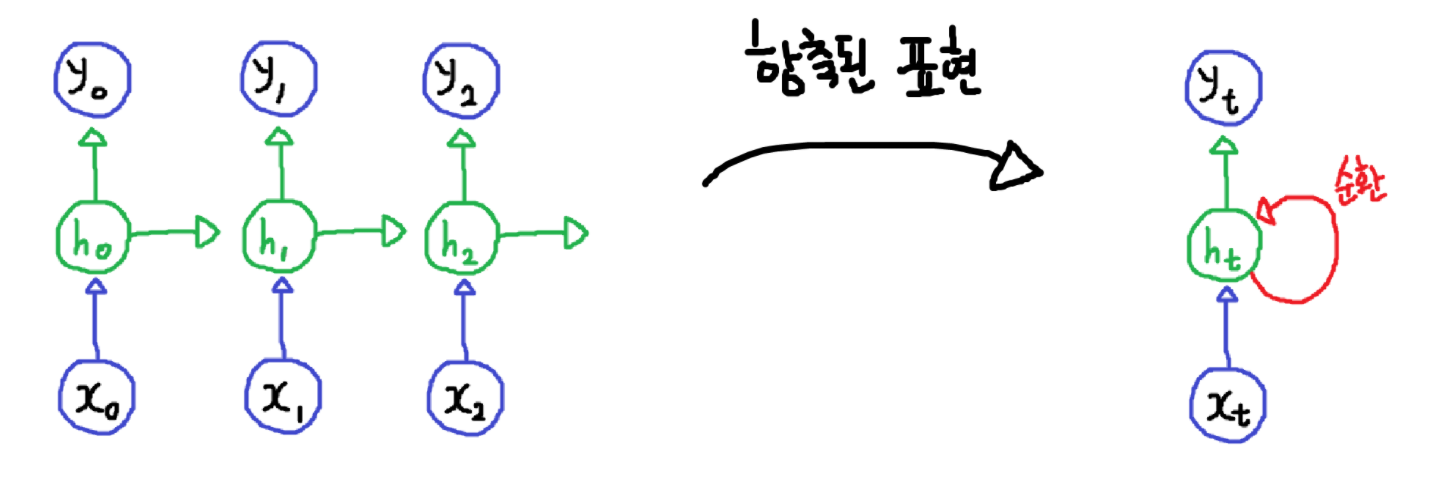

- 아래와 같이 표현됩니다~.

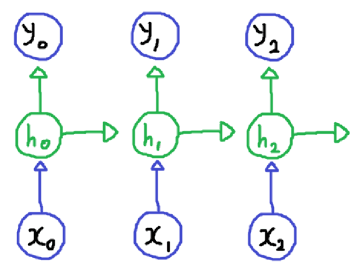

### RNN으로 데이터 학습 원리

- RNN은 이전 시점의 Hidden State의 출력값이, 다음 Hidden State 계산의 입력값으로 들어갑니다.
- RNN의 학습은 다음과 같이 이뤄집니다.
  - **이전 데이터들로 만들어진 정보(Hidden Layer 출력값)를, 다음 글자를 예측하는데 사용됩니다.**

  - 학습할때 입력데이터로 **['안', '녕, '하', '세, '요]** 를 넣어서 학습하겠다고 하겠습니다.

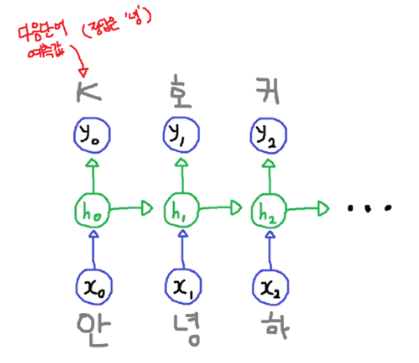

- 나름대로 '안' 다음 글자를 'K'로, 예측했고.. 이런식으로 각각 다음글자를 ['K', '호', '커'] 로 예측이 잘 안되었습니다.
- 이후에 GD를 통해, 오차율이 적도록 히든레이어 가중치 값이 업데이트 됩니다.
  - 그러면 점점 예측을 잘하게 될 것입니다.

- 아래 그림은 epoch을 반복해서 점점 똑똑해졌을 때.. 학습하고 있는 이미지입니다.
  - '녕' 까지는 예측이 잘 되었고, '!' 랑 'ㅋ' 는 오류가 있네요.

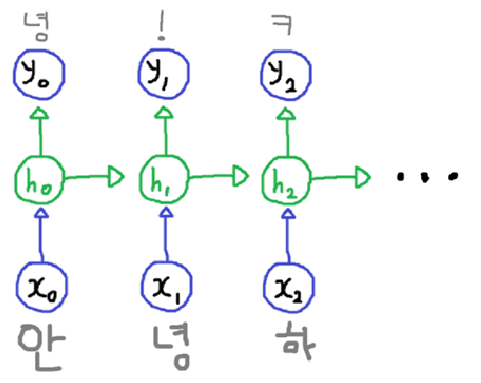

조금 더 자세하게 이야기 하자면, Hidden layer에서는 입력된 단어들의 의미 벡터를 기반으로 <br>
이전 시점의 정보와 결합하여 문맥을 반영한 상태를 만들고,
이를 통해 다음 단어의 확률 분포를 예측합니다.

여기서 의미벡터란? 단어의 의미를 수치화 한 것을 말합니다.

### RNN으로 추론 원리

- 학습이 완료되면 이제 추론에 사용됩니다.
  - 입력 데이터는 이거 하나면 됩니다. ['안'] 한글자요.
  - 그러면 다음 글자들이 연속적으로 예측할 수 있습니다.
  
- 아래 gif는 추론을 하는 예시입니다.

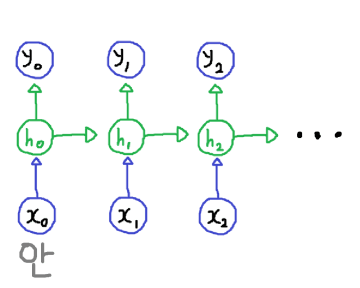

흐름은 다음과 같습니다.

* step 1 : 입력 : 안
    - hidden state (예 h0) 에서 "안"의 의미벡터값 기반으로 다음 단어를 확률 기반으로 예측
  
    - 출력 : 녕 (예측)
* step 2 : 입력 : 녕
    - 이전 h0의 정보(벡터값) + 새로운 hidden state h1
    - 출력 : 하 (다음들자 예측)
* step 3 : 입력 : 하
    - 이전 h0의 정보 + h1의 정보 + 새로운 hidden state h2
    - 출력 : 세 (다음들자 예측)


이런 식으로 예측값을 출력 합니다.



<br/>

- RNN 원리를 정리해보겠습니다.
  - RNN의 핵심 아이디어는 **이전에 사용했던 정보들을, 다음 단어를 예측하는데 사용** 하는 겁니다.
    - 예측해보고, GD로 점점 에러가적도록 파라미터를 업데이트 합니다.
    - 이후에 실제로 사용할때는 RNN이 추론한 글자들을 출력하면 됩니다.

### RNN의 단점


- Sequence가 길어질수록 초기 정보(Hidden State)들이 반영이 잘안됩니다.
  - 과거 기억을 잊게된다로 비유할 수 있겠습니다.
  - 10분전에 들을말 기억하기 vs 1시간전 기억하기와 같이 모델 구조상 오래된 정보는 기억을 못합니다.

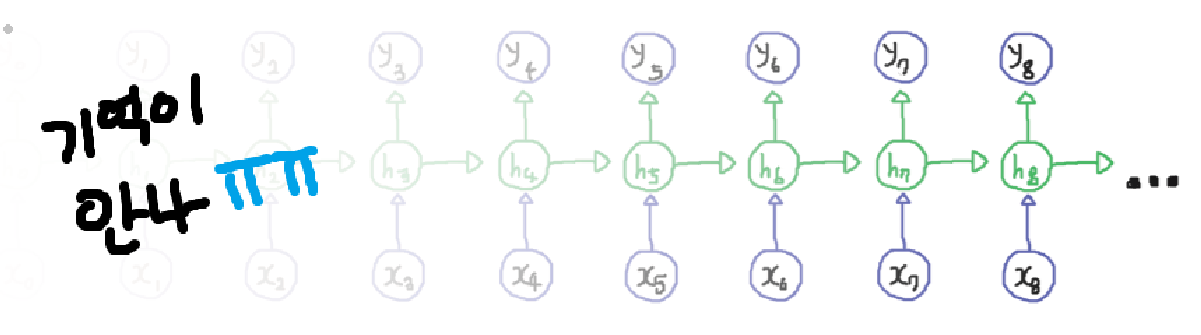

- 또한 Gradient Decent를 하는데 앞 부분은 학습이 잘 되는데, 뒷 부분은 학습이 잘 안됩니다.
  - GD를 위해 기울기 계산 (Backpropagation)을 합니다.
  - 그때 기울기 소실 (점점 0으로 수렴) 문제나, 학습이 망가져 기울기 폭발 (점점 거대한 값으로 폭발) 문제가 있습니다.

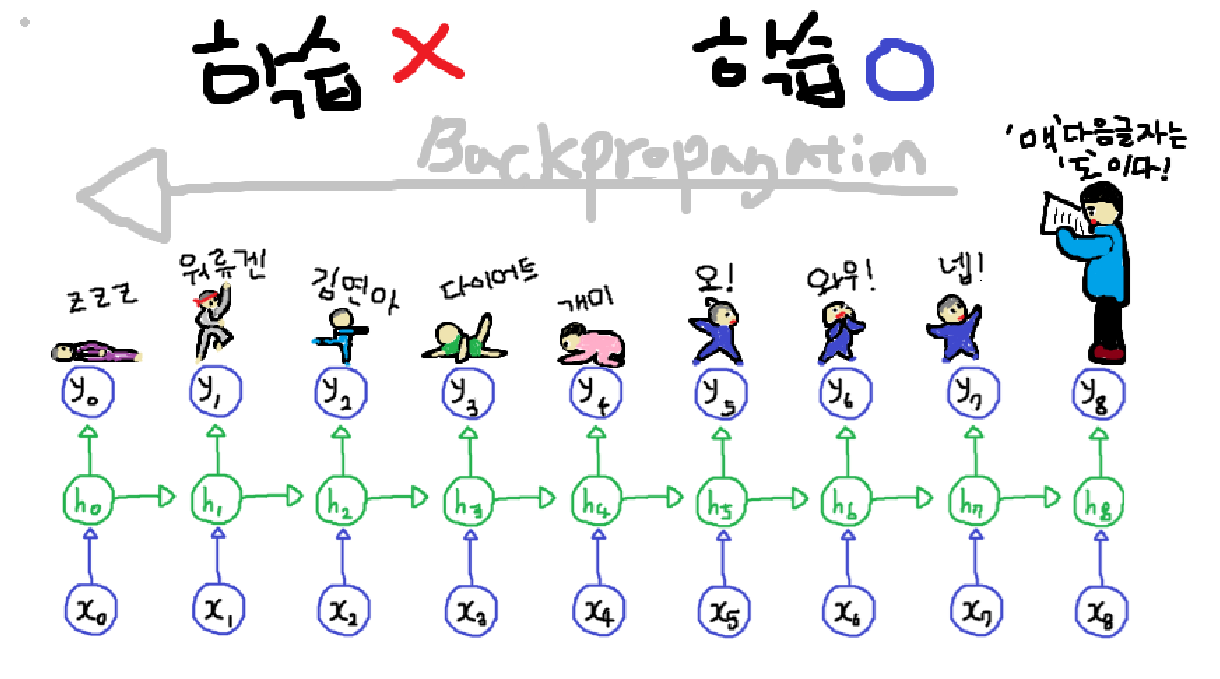

- 기울기 소실, 폭발문제 해결하기 위해 다른알고리즘들(LSTM)이 나왔지만, 여전히 오래전 정보를 잊어버리는 문제는 존재합니다.

## Transformer 모델에서 RNN 단점을 근본적으로 해결!


- 이러한 문제는 **Transformer 모델** 에서 근본적으로 해결되었습니다
- Transformer는 RNN처럼 과거 정보를, 다음 Layer로 전달해주는 방식을 버렸어요.
  - 참고로 RNN은 이전 Hidden Layer값이 모든 과거 정보를 내포하고 있었죠.
  - Transformer 모델은 각 토큰이 입력값들의 정보들을 서로 참고하면서 문장 전체 정보를 나눠 갖습니다.
  - 이를 self-attention 이라고 합니다.
  - 그 다음 Layer의 출력값을 만들어냅니다!
    - 장기기억 소실문제가 해결되었습니다.
    - 기울기 소실, 폭발 문제가 해결되었습니다.
    - 현대 딥러닝은 대부분 Transformer 모델을 기반으로 사용합니다




* self-attention에 대한 예시 입니다.

  - '안' '녕' '하' '세' '요' 라는 단어를 예를 들자면, self attention의 과정은 다음과 같습니다.

  1. 각 단어가 벡터값으로 변환됨
  2. 각 단어의 벡터는 3개의 값으로 변환 QKV
    * Q (Query): 내가 찾고 싶은 정보
    * K (Key): 내가 어떤 정보를 갖고 있는지
    * V (Value): 실제 전달할 정보

  - 만약에
    1. 요 라는 정보 입력
        * 요 -> Q

    2. 다른 단어들과 매칭후, 얼마나 관련있는지 점수 계산
        * Q(요) vs K(안)
        * Q(요) vs K(녕)
        * Q(요) vs K(하)
        * Q(요) vs K(세)

    3. 중요도 결정 (softmax)
        * [안: 0.1, 녕: 0.2, 하: 0.3, 세: 0.4]

    4. 정보 업데이트
        * 새로운 요 = 0.1×V(안) + 0.2×V(녕) + 0.3×V(하) + 0.4×V(세)

    5. 위 과정을 모든 단어가 함
        * '안'도 다른 애들 참고해서 업뎃
        * '녕'도 참고해서 업뎃
        * '하'도 참고해서 업뎃

    결국에는 각 단어가 다른 단어들을 전체 정보를 반영해서 자기 벡터를 다시 만듭니다.

# 2. Attention과 Transformer 모델
- 시계열 모델(RNN 등) 한계를 극복하기 위해 탄생했습니다.
- Transformer는 Attention을 여러개 사용하는 모델입니다.
  - Attention이 무엇인지 다시 보시죠.



### Attention
- 각 단어가 다른 단어들과 유사한 정도를 계산합니다.
- 이 유사도을 가중치로 사용해서 다른 토큰들의 정보를 섞어 새로운 벡터를 만듭니다.


- 더 정확히 말하면 다음과 같습니다.
  - 그 동안 일반적인 선형계산에는 우리는 y = WX + b로 계산했죠?
    - 하나의 Weight 행렬을 사용합니다.
  - Attention을 계산할 때는 3개의 Weight 행렬을 사용합니다. 3개는 이름이 있습니다.
    - Query / Key / Value 행렬 입니다.
    - 이 Weight값은 학습 대상이 됩니다~.

<br/>

- 그럼 아래 내용을 봅시다.
  - 복잡한 수식은 건강상 모자이크 처리 했습니다. ^^
  - 각 단어의 학습된 임베딩 벡터값을 조회합니다. ("의미공간"의 벡터값)
    - 신조어는 subword로 쪼개서 벡터값을 가짐
  - 그리고 이를 선형변환하여 각각 XW_query, XW_key, XW_value 값을 구합니다.
  - 이후에 Attention 수식에 대입하여(V를 가중합 하여) output을 구할 수 있습니다.
  - 이 output은 문맥이 반영된 벡터 가 됩니다.
    다른말로, "문맥표현공간"의 벡터값이 됩니다.
    - 엄청난 고차원의 문맥 세계의 입주민이 되는겁니다.

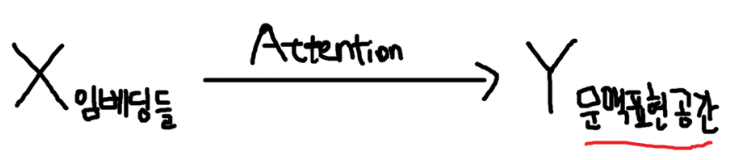

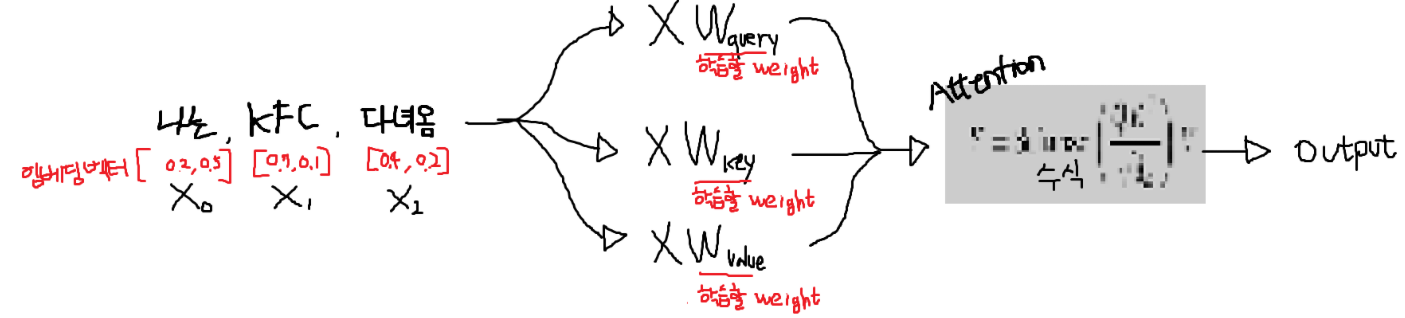

- 위 내용을 요약해보겠습니다.
- 먼저 아래와 같이 Q, K, V 는 각각의 Weight값을 곱한값입니다.
  - 임베딩 값에 선형변환을 한겁니다.

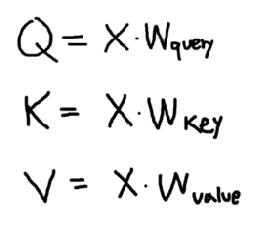

- 이후에 수식은 다음과 같이 요약할 수 있습니다.
  - Attention 함수는 아까 모자이크 했던 수식입니다.

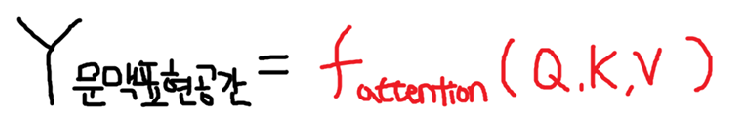

### Transformer 구조
- Transformer의 구조는 아래와 같습니다.
  - 아래 이미지 출처 : https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)

- Tranformer는 Encoder들 + Decoder들 조합으로 구성되어 있습니다.
  - Encoder, Decorder 모두 Attention과 MLP의 조합으로 구성되어 있습니다.
  - Encoder : 입력된 문장의 문맥을 이해합니다.
  - Decoder : 입력 문장 정보를 이용해서, 출력 문장을 생성합니다.

- 인코더 : 입력 문장 안의 모든 토큰이 서로를 바라보며, **문맥을 반영한 의미 벡터** 를 만드는 단계입니다.
  - "I went to the bank to deposit money."
  - 여기서 "bank"의 의미를 정확히 알기 위해서 앞의 "deposit" 같은 단서가 있으면 좋겠죠?
  - 인코더에서의 Self-Attention은 다음을 합니다
    - 각 단어(토큰) 임베딩 -> Q, K, V로 선형변환
    - 모든 토큰끼리 Q·K 행렬곱으로 상호 유사도를 구하고 softmax를 이용해서 가중치를 만들어요.
    - 그다음 가중치로 Value 벡터들을 가중합 해서 문맥을 반영한 최종 문맥공간에서의 벡터값을 만들어요.
  - 이렇게 얻은 벡터값을 가지고 MLP를 돌리면 인코더의 역할은 끝이에요.
  - MLP가 돌면서 점점 문맥을 더 잘 이해하게 됩니다.
    - Attention 과정은 어떤 단어를 더 참고할지
    - MLP로 그 정보를 어떻게 문맥을 해석할지 보는 과정이라고 생각하시면 됩니다.





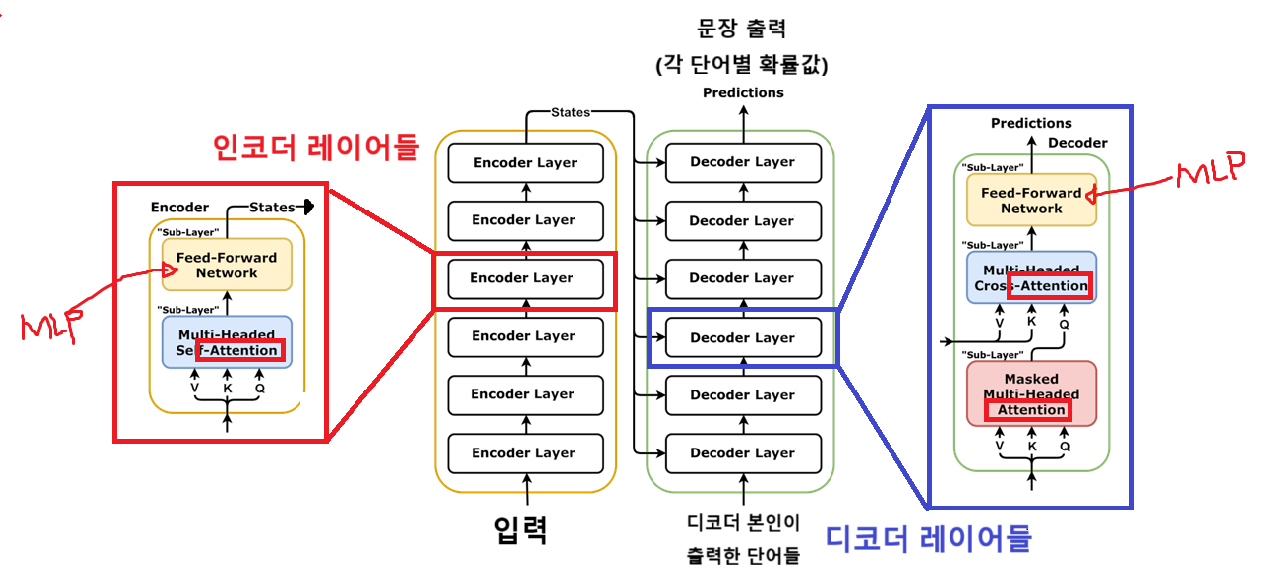

- 디코더도 볼까요?
  - 디코더는 **인코더의 출력값을 바탕으로 문장**을 생성해요. 이때 2개의 어텐션을 사용합니다.
  - 만약에 나는 은행에 갔다. 라고 단어를 생성한다고 가정 해 볼까요?
    1. `나는` 여기까지 보고 다음단어 예측
    2. `나는 은행에` 여기까지 보고 다음단어 예측
    3. `나는 은행에 돈을` 여기까지 보고 다음단어 예측 이런식으로 반복을 합니다.
    
    디코더는 인코더가 만든 문맥공간의 벡터값을 참고해서
    지금까지 생성한 문맥을 가지고 다음단어를 예측하는 기능을 맡고 있습니다.
    
   - 아까 2개의 어텐션을 사용한다고 말했죠?
     1. Masked 어텐션은 지금까지 내가 생성한 단어들만 보고 문맥을 파악하는 기능담당
     2. Cross 어텐션은 -> 인코더를 통해서 문맥의미공간을 참고하는 역할을 합니다.
         - 그래서 구조적으로 모든 디코더 레이어가 인코더의 최종 출력(마지막 레이어)를 참조하는 것입니다.
   - 그리고 끝으로 MLP 돌려서 최종 출력값을 비선형적으로 가공해서 표현합니다.



- 요약하면 다음과 같습니다.
  - 입력 문장 --> [Encoder × N개] --> 문맥 벡터
    - Encoder 여러개로 정교한 이해를 합니다.
  - 출력 문장 --> [Decoder × N개] --> 최종 문장 예측
    - Decoder 여러개로 점차 정교한 문장을 만들어냅니다.
    

# 3. Transformer 모델을 응용하여 만들 수 있는 것들

### 모달이란?
  - 인간이 정보를 인식할 수 있는 형태를 모달(Modality) 이라고 합니다.
    - Text, Image, Audio, .. 여러 Sensor 값들이 될 수 있습니다.
    - 여러 모달을 다루는 모델을, **멀티모달 모델**이라고 합니다.

### 모달별 Transformer 활용 원리

- Text 모달
  - 문맥 전체를 더 잘 이해하도록 만들 수 있습니다.
  - 문맥에서 벗어나지 않는 문장을 만들어 낼수도 있습니다.

<br/>

- Image 모달
  - 이미지를 작은 단위로 잘라서 하나의 토큰처럼 취급합니다.
    - 이 단위를 패치(patch)라고 합니다.
  - 함께 어울릴 수 있는 패치들을 이해합니다.
    - 이러한 패치들의 조합을 확률 기반으로 선택하여, 자연스러운 이미지 생성할수도 있습니다. (DALL-E 원리)


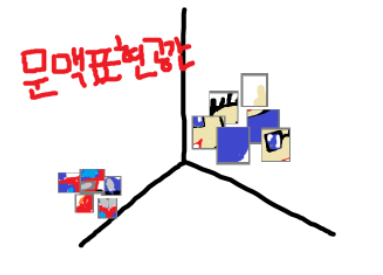


<br/>

- Text와 Image의 유사도 비교
  - Text의 토큰들과, Image의 패치들을 같은 "문맥표현공간"의 벡터 값으로 사용합니다.
  - Image 패치들이, 어떤 Text와 가장 관련이 있는지 알아낼 수 있습니다.
  - 이를 이용하여 사물 인식이 가능합니다.

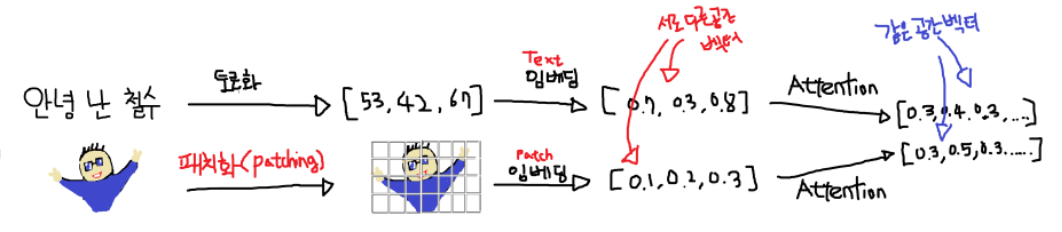

### 모달별 Transformer 활용 사례
  - Text를 입력하면 Image가 생성됩니다.
    - Text to Image 라고 합니다.
    - 예시 : "강아지 사진 만들어줘"
  - Text + Image를 동시에 입력하고, 결과를 받을 수 있습니다.
    - Image-Text to Text 라고 합니다.
    - 예시 : (사진을 주고), "이 사진은 낮이니 밤이니?" 라고 질문 가능합니다.
  - Text를 입력하면, 사람의 음성 Voice를 생성되도록 할 수 있습니다.
    - Text to Speech 라고 합니다.

<br/>

- 아래와 같이 **Transformer 모델이 발표된 이후, 정말 빠르게 Multi-Modal 시대가 되었습니다.**

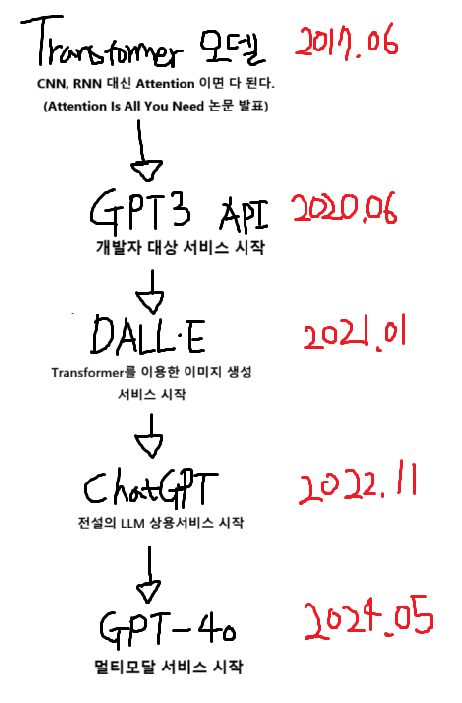

# 4. Foundation 모델

### 파운데이션 모델이란?
- Transformer 이후 시대에는 **Foundation 모델** 이라는 말이 생겼습니다.
- Foundation 모델은 '칭호' 같은 건데요. 다음 조건이 되면 됩니다.
  - **방대한** 범용 데이터로 학습하고
  - 다양한 목적에 맞게 **파인튜닝** 해서 사용 가능한
  - **대규모** 파라미터를 가진 모델

- 근데 방대한의 규모랑, 대규모의 범위는 정해진게 없습니다. ^^
  
<br/>

### 파운데이션 모델 종류 (대표적인 것 위주)
다음은 가중치 비공개 모델 입니다. (API 형태로만 사용)
  - GPT 모델들 (OpenAI)
  - Claude 모델 (Anthropic)
  - Gemini 모델 (Google)

대표적인 공개 모델입니다. (오픈소스, 개인도 파인튜닝 가능)
 - LLaMA (Meta) : 공개 모델의 대표모델이라고 말할 수 있습니다.
 - Qwen (Alibaba) : Qwen3가 25년 4월에 출시되어 매우 인기 많아요.
 - gpt-oss (OpenAI) : 25년 8월 공개함, 연구자에게 매우 인기 많아요.

### 파운데이션 모델 살펴보기

- 허깅페이스에서 모델을 검색해봅시다.
- phi 라고 검색하면 phi-4 multimodal이 눈에 뜁니다.
  - 참고로 허깅페이스에서 멀티모달이라고 써있으면, Image, Text 모두 입력이 가능하다는 의미로 자주 쓰입니다.
  - Image, Text 동시에 출력가능한 모델은 거의 없는것 같습니다.

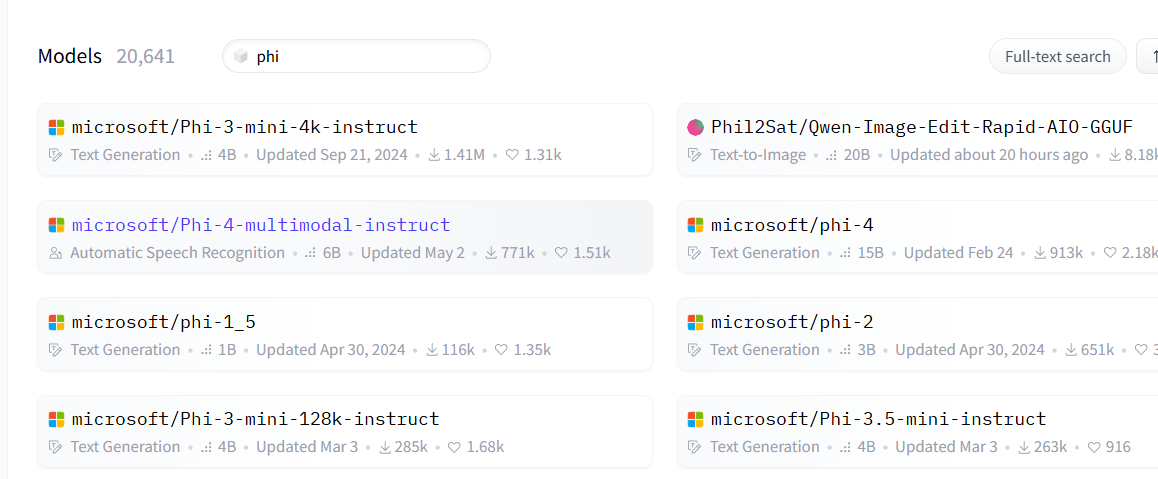

- qwen을 검색해봅시다.
  - Qwen-VL 이 눈에 뜁니다.
  - Vision, Language 라는 의미로 VL이라고 하며 이미지와 언어 동시에 입력받을 수 있는 멀티모달 모델입니다.
- 이렇게 모델마다 이름이 다르고, 멀티모달 모델과 아닌 모델 여러개가 동시에 존재합니다.

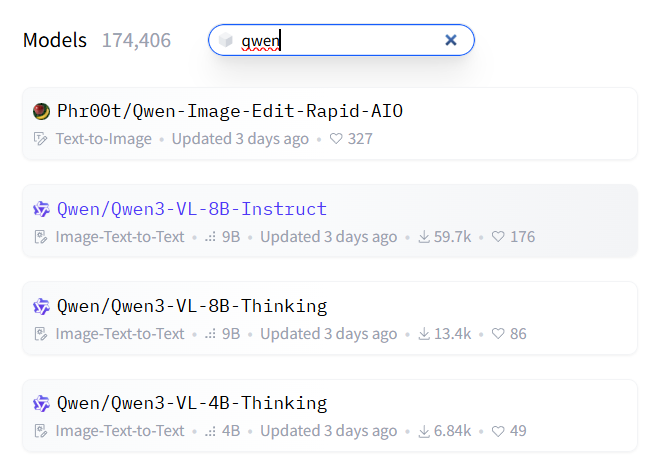

- 이미지 생성모델의 대표주자 중 하나인 Stable Diffusion도 살펴봅시다.
  - 로컬 PC 환경(또는 코랩)에서 이미지를 생성할 수 있습니다.

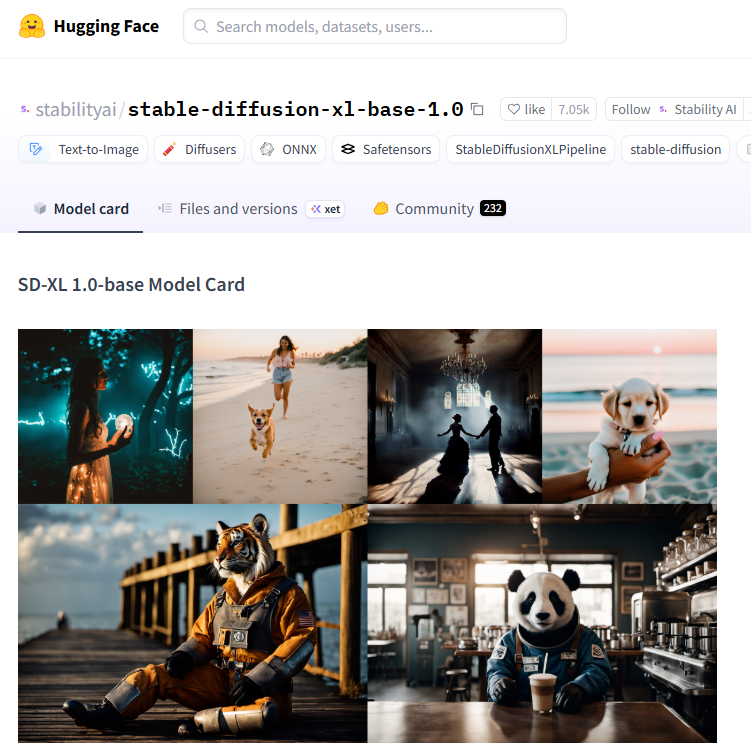

- 그 밖에 허깅페이스에 Models > Tasks 를 눌러서 더 많은 모델을 볼 수 있습니다.
  - Audio-Text-to-Text : 음성 or Text를 이해하는 멀티모달 모델
  - Text-To-Speech : 텍스트를 사람의 음성으로 읽어주는 모델

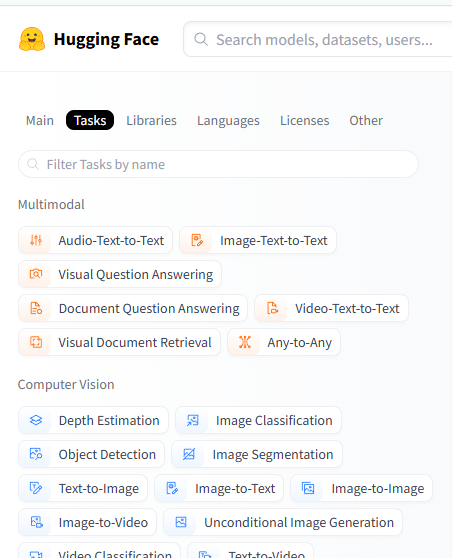

- 여러가지 테스트를 통해 나만의 AI Application을 제작할 수 있겠죠?

# 5. Transformer 기반, 사물인식 모델


- 이미지에서 미리 학습된 객체들을 탐지하는 모델을 돌려보겠습니다.
  - Object Detection 모델입니다.

- 사용하는 모델은 Transformer로 만들어진 YOLOS 모델입니다.
  - CNN 기반 모델로 유명한 YOLO 모델은 (You Only Look Once) 이고요.
  - 지금 사용할 Transformer 기반 YOLOS 모델은 (You Only Look at One Sequence) 입니다.
    - 이름을 패러디한거예요.
    - hustvl/yolos-small (https://huggingface.co/hustvl/yolos-small)


Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


preprocessor_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/123M [00:00<?, ?B/s]

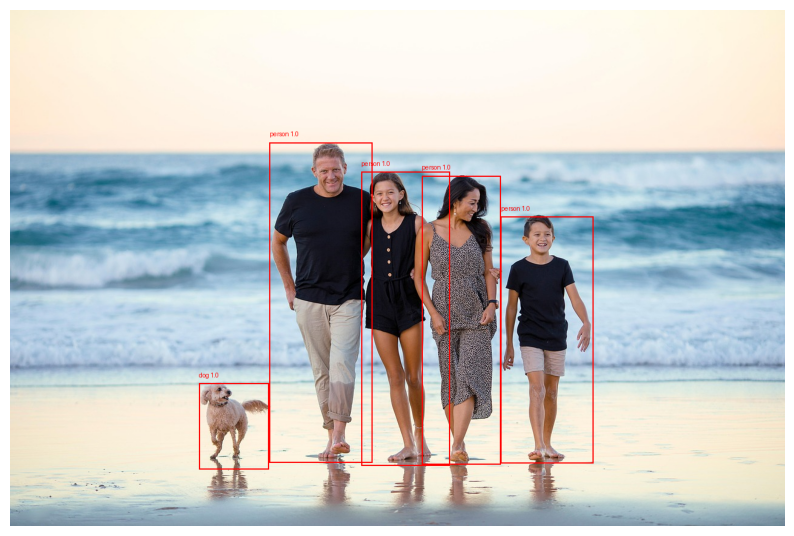

In [1]:
from transformers import YolosImageProcessor, YolosForObjectDetection
import requests
from PIL import Image, ImageDraw   # 이미지 처리할때 쓰는 라이브러리
import torch
import matplotlib.pyplot as plt

# 이미지 로드 후 전처리
url = 'https://cdn.pixabay.com/photo/2021/07/09/02/29/family-6398107_1280.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# 전처리기, 모델 로드
feature_extractor = YolosImageProcessor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small')

# 입력 전처리
inputs = feature_extractor(images=image, return_tensors="pt")

# 모델추론
outputs = model(**inputs)

# 후처리
target_sizes = torch.tensor([image.size[::-1]]) # PIL라이브러리가 가로세로(w,h) but 모델은 세로가로(h,w)
results = feature_extractor.post_process_object_detection(
    outputs, threshold=0.7, target_sizes=target_sizes)[0]  # 신뢰도가 70% 이상인 것만 골라
                                                           # 첫번쨰 이미지의미 (0번 인덱스)

# 이미지위에 빨강 사각형박스 그릴 준비
draw = ImageDraw.Draw(image)

# 욜로가 찾은 사물을 하나씩 꺼낸 다음, 빨간상자 그리고 정보(이름,정확도) 적기
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    label_text = f"{model.config.id2label[label.item()]} {round(score.item(), 2)}"

    draw.rectangle(box, outline="red", width=2) # 빨간 사각형
    draw.text((box[0], box[1] - 20), label_text, fill="red") # 빨간색 글씨

# 결과 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

# 6. Transformer 기반, 이미지 생성 멀티모달 모델
- Text to Image 모델로, 이미지를 생성해봅시다.
  - 입력은 Text이고, 출력은 Image 입니다. 두 가지 모달을 사용했으니 멀티모달 모델입니다~.
- 이미지 생성방법인 **Diffusion 알고리즘**은 다음과 같이 동작됩니다.
  - 학습 : 원본 이미지에 노이즈를 조금 추가하고 어디에 얼마나 노이즈를 추가되었는지 예측합니다. 이를 반복합니다. (그림위에 낙서하는법을 학습)
  - 추론 : 완전한 노이즈로 시작해서, 노이즈를 점점 제거하면서 복원하는 방법으로 이미지를 생성합니다. (낙서를 지우면서 그럴듯한 그림으로 완성)

- 이미지 출처 : https://developer.nvidia.com/blog/understanding-diffusion-models-an-essential-guide-for-aec-professionals/

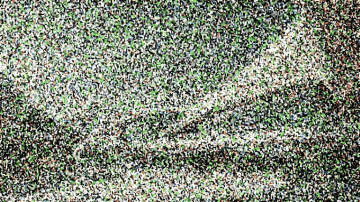

- 다음과 같은 모델을 사용했습니다.
  - "stabilityai/sd-turbo 모델입니다. (Stable Diffusion 2.1)
    - https://huggingface.co/stabilityai/sd-turbo
    - 적은 노이즈 제거 Step으로 빠르게 이미지 생성이 가능한 모델입니다.

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.73G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/1 [00:00<?, ?it/s]

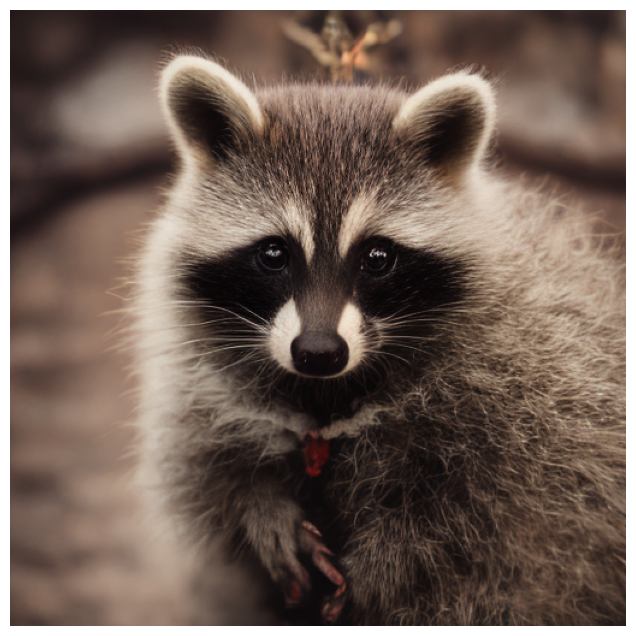

In [2]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo",
                                                 torch_dtype=torch.float16,
                                                 variant="fp16")
pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]

# 이미지 출력
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

['.gitattributes', 'LICENSE.md', 'README.md', 'image_quality_one_step.png', 'model_index.json', 'output_tile.jpg', 'prompt_alignment_one_step.png', 'scheduler/scheduler_config.json', 'sd_turbo.safetensors', 'text_encoder/config.json', 'text_encoder/model.fp16.safetensors', 'text_encoder/model.safetensors', 'tokenizer/merges.txt', 'tokenizer/special_tokens_map.json', 'tokenizer/tokenizer_config.json', 'tokenizer/vocab.json', 'unet/config.json', 'unet/diffusion_pytorch_model.fp16.safetensors', 'unet/diffusion_pytorch_model.safetensors', 'vae/config.json', 'vae/diffusion_pytorch_model.fp16.safetensors', 'vae/diffusion_pytorch_model.safetensors']


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/2 [00:00<?, ?it/s]

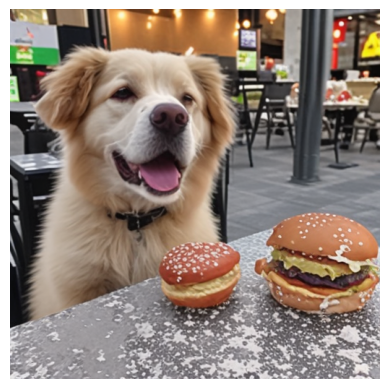

In [8]:
import torch
from diffusers import AutoPipelineForText2Image
import matplotlib.pyplot as plt
from huggingface_hub import list_repo_files

files = list_repo_files("stabilityai/sd-turbo")   # 파일 명 확인
print(files) 

# 1. 모델 로드
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.bfloat16,      # [옵션]Blackwell 아키텍처 BF16 성능좋음
    variant="fp16",                  # [옵션]저장 공간 및 로딩 속도 절약
    use_safetensors=True             # .bin과 .safetensors 중 safetensor 파일을 활용
)

# 2. GPU(CUDA)로 이동
pipe.to("cuda")

# 프롬프트 입력
prompt = "The puppy is eating a hamburger at McDonald's."

# [옵션] 이미지 로드시 PyTorch 컴파일 최적화 (추론용)
# 첫 실행 시 1~2분 정도 소요되지만, 이후 생성 속도가 약 20% 이상 빨라집니다.
pipe.unet = torch.compile(pipe.unet, mode="reduce-overhead")

# 4. 이미지 생성 테스트
image = pipe(prompt=prompt,
             num_inference_steps=2,  # 이미지 얼마나 정교하게 만들지 (0~30 사이값)
             guidance_scale=1).images[0] # 프롬프트를 얼마나 강하게 따를지 (0~10사이값)

# 5. 결과 확인 1
plt.imshow(image)
plt.axis("off")
plt.show()

# 8. 끝으로
  - Transformer 모델은 Attention들을 이용하여 만들어졌습니다.
  - 이는 Foundation 모델 시대를 열었고, 수 많은 응용으로 AI 시대가 되었습니다.
  - 거의 모든 SW에 AI를 활용할 수 있고, 더 나아가 Physical AI 개념까지 나오고 있습니다.
  - 오늘 수업을 통해 Transformer기반 모델을 다양하게 활용하셔서, 여러분의 프로젝트에 날개가 되길 바랍니다.

<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  